# Notebook 0 — Exploratory Data Analysis & Missingness

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

This notebook performs:
1. Data loading and initial inspection
2. Cognitive domain mapping (51 variables → 7 domains)
3. Tier 1 filtering (≥50% missing threshold)
4. Row filtering (at least 1 non-missing value among eligible variables)
5. Missingness visualisations

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

DATA_DIR = '../data'
RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading

In [2]:
# Load main dataset
df = pd.read_excel(os.path.join(DATA_DIR, '0_tests2.xlsx'))
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}, Columns: {df.shape[1]}')
df.head()

Dataset shape: (22075, 31)
Rows: 22,075, Columns: 31


,ID,Sex,AGE_INJURY,TSI_TO_ASSESSMENT_DAYS,TSI_TO_ASSESSMENT_YEARS,C_UNITATMEDICA,OPERSONA,OESPAI,OTEMPS,ASPAN,...,MDIGITS,MLLETRES,MRAVLT075,MRAVLT015,MRAVLT015R,FETMTB,FEWCSTC,FEWCSTE,FESTROOP,FEPMR
0,584275,Male,30.372603,13222.538252,36.226132,11,7.0,5.0,23.0,NaN,...,NaN,1.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,20.0
1,584275,Male,30.372603,13712.580984,37.568715,11,7.0,5.0,23.0,NaN,...,NaN,7.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,15.0
2,995293,Male,19.736986,14152.664942,38.774424,24,7.0,5.0,23.0,7.0,...,4.0,11.0,32.0,3.0,0.0,220.0,5.0,26.0,13.0,26.0
3,995293,Male,19.736986,15431.614537,42.278396,24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,892126,Female,33.087671,14068.599398,38.544108,1,7.0,5.0,23.0,6.0,...,NaN,NaN,26.0,4.0,0.0,NaN,NaN,NaN,NaN,11.0


In [3]:
# Load clinical unit lookup table
df_units = pd.read_excel(os.path.join(DATA_DIR, '0_UNITATM.xlsx'))
print(f'Unit lookup shape: {df_units.shape}')
df_units.head()

Unit lookup shape: (41, 3)


,C_UNITATM,N_UNITATM,N_GRUP
0,0,** NO ASSIGNAT **,NaN
1,1,Paraplegia completa,Lesió medul·lar
2,2,Paraplegia incompleta,Lesió medul·lar
3,3,Tetraplegia completa,Lesió medul·lar
4,4,Tetraplegia incompleta,Lesió medul·lar


In [4]:
# Initial inspection
print('=== Column Names ===')
print(df.columns.tolist())
print(f'\n=== Data Types ===')
print(df.dtypes.value_counts())
print(f'\n=== Basic Statistics ===')
df.describe()

=== Column Names ===
['ID', 'Sex', 'AGE_INJURY', 'TSI_TO_ASSESSMENT_DAYS', 'TSI_TO_ASSESSMENT_YEARS', 'C_UNITATMEDICA', 'OPERSONA', 'OESPAI', 'OTEMPS', 'ASPAN', 'ATMTA', 'APARAULA', 'ACOLOR', 'APARAULACOLOR', 'VPWAISIII', 'LLAMINATB', 'LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB', 'VPIMATGES', 'VCCUBS', 'MDIGITS', 'MLLETRES', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R', 'FETMTB', 'FEWCSTC', 'FEWCSTE', 'FESTROOP', 'FEPMR']

=== Data Types ===
float64    28
int64       2
object      1
Name: count, dtype: int64

=== Basic Statistics ===


,ID,AGE_INJURY,TSI_TO_ASSESSMENT_DAYS,TSI_TO_ASSESSMENT_YEARS,C_UNITATMEDICA,OPERSONA,OESPAI,OTEMPS,ASPAN,ATMTA,...,MDIGITS,MLLETRES,MRAVLT075,MRAVLT015,MRAVLT015R,FETMTB,FEWCSTC,FEWCSTE,FESTROOP,FEPMR
count,22075.000000,22075.000000,22075.000000,22075.000000,22075.000000,17284.000000,17282.000000,17286.000000,15611.000000,12575.000000,...,15373.000000,10457.000000,15523.000000,14281.000000,14199.000000,8244.000000,5420.000000,5422.000000,5532.000000,14682.000000
mean,550035.078596,45.860728,783.338652,2.146133,13.887339,6.820991,4.643965,21.085387,5.561655,74.543459,...,3.910297,7.727933,36.458867,6.482529,9.895838,142.952450,4.080258,17.287901,0.271511,28.712709
std,261985.304364,14.541727,1790.491932,4.905457,4.399836,0.643113,0.946650,4.705071,1.219514,60.267230,...,1.118392,2.912013,13.023619,4.167853,4.848667,102.431882,2.220295,15.420130,8.120746,14.007729
min,100067.000000,16.008219,0.719595,0.001971,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,-33.000000,0.000000
25%,324764.000000,35.317808,89.404861,0.244945,10.000000,7.000000,5.000000,22.000000,5.000000,40.000000,...,3.000000,6.000000,27.000000,3.000000,7.000000,82.000000,2.000000,5.000000,-5.000000,18.000000
50%,543980.000000,47.493151,176.455313,0.483439,14.000000,7.000000,5.000000,23.000000,6.000000,57.000000,...,4.000000,8.000000,36.000000,6.000000,11.000000,117.000000,5.000000,13.000000,0.000000,28.000000
75%,777035.000000,56.523288,458.596667,1.256429,17.000000,7.000000,5.000000,23.000000,6.000000,87.000000,...,5.000000,10.000000,46.000000,10.000000,14.000000,174.000000,6.000000,26.000000,5.000000,38.000000
max,999852.000000,89.336986,22096.511030,60.538386,28.000000,7.000000,5.000000,24.000000,9.000000,999.000000,...,8.000000,20.000000,75.000000,15.000000,37.000000,999.000000,6.000000,93.000000,42.000000,150.000000


## 2. Cognitive Domain Mapping

Map the 51 variables to 7 cognitive domains. The domain structure is based on standard neuropsychological assessment batteries used in acquired brain injury rehabilitation.

In [5]:
# Complete cognitive domain mapping
# This maps ALL cognitive test variables to their respective domains
DOMAINS_FULL = {
    'Orientation': [c for c in df.columns if c.startswith('O')],
    'Attention': [c for c in df.columns if c.startswith('A')],
    'Visuoperception': [c for c in df.columns if c.startswith('VP')],
    'Language': [c for c in df.columns if c.startswith('L')],
    'Visuoconstruction': [c for c in df.columns if c.startswith('VC')],
    'Memory': [c for c in df.columns if c.startswith('M')],
    'Executive Function': [c for c in df.columns if c.startswith('FE')]
}

# Exclude non-cognitive variables that share a domain prefix but are not
# cognitive tests (e.g. AGE_INJURY starts with 'A' but is a demographic).
NON_COGNITIVE_VARS = {'AGE_INJURY'}
DOMAINS_FULL = {d: [c for c in v if c not in NON_COGNITIVE_VARS]
                for d, v in DOMAINS_FULL.items()}

# Print domain mapping
all_cognitive_vars = []
for domain, variables in DOMAINS_FULL.items():
    all_cognitive_vars.extend(variables)
    print(f'{domain}: {len(variables)} variables — {variables}')

print(f'\nTotal cognitive variables identified: {len(all_cognitive_vars)}')

# Non-cognitive columns
non_cognitive = [c for c in df.columns if c not in all_cognitive_vars]
print(f'Non-cognitive columns: {non_cognitive}')

Orientation: 3 variables — ['OPERSONA', 'OESPAI', 'OTEMPS']
Attention: 5 variables — ['ASPAN', 'ATMTA', 'APARAULA', 'ACOLOR', 'APARAULACOLOR']
Visuoperception: 2 variables — ['VPWAISIII', 'VPIMATGES']
Language: 4 variables — ['LLAMINATB', 'LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB']
Visuoconstruction: 1 variables — ['VCCUBS']
Memory: 5 variables — ['MDIGITS', 'MLLETRES', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R']
Executive Function: 5 variables — ['FETMTB', 'FEWCSTC', 'FEWCSTE', 'FESTROOP', 'FEPMR']

Total cognitive variables identified: 25
Non-cognitive columns: ['ID', 'Sex', 'AGE_INJURY', 'TSI_TO_ASSESSMENT_DAYS', 'TSI_TO_ASSESSMENT_YEARS', 'C_UNITATMEDICA']


## 3. Missingness Analysis

In [6]:
# Compute per-variable missingness for cognitive variables
miss_pct = df[all_cognitive_vars].isnull().mean().sort_values(ascending=False) * 100

miss_df = pd.DataFrame({
    'Variable': miss_pct.index,
    'Missing %': miss_pct.values,
    'N Missing': df[miss_pct.index].isnull().sum().values,
    'N Present': df[miss_pct.index].notna().sum().values
})

# Assign domain
var_to_domain = {}
for domain, variables in DOMAINS_FULL.items():
    for v in variables:
        var_to_domain[v] = domain
miss_df['Domain'] = miss_df['Variable'].map(var_to_domain)

print('=== Per-Variable Missingness ===')
print(miss_df.to_string(index=False))
print(f'\nVariables with ≥50% missing: {(miss_pct >= 50).sum()}')
print(f'Variables with <50% missing: {(miss_pct < 50).sum()}')

=== Per-Variable Missingness ===
      Variable  Missing %  N Missing  N Present             Domain
     LLAMINATB  98.650057      21777        298           Language
       FEWCSTC  75.447339      16655       5420 Executive Function
       FEWCSTE  75.438279      16653       5422 Executive Function
      FESTROOP  74.939977      16543       5532 Executive Function
      APARAULA  74.939977      16543       5532          Attention
        ACOLOR  74.939977      16543       5532          Attention
 APARAULACOLOR  74.939977      16543       5532          Attention
        FETMTB  62.654587      13831       8244 Executive Function
     VPWAISIII  62.070215      13702       8373    Visuoperception
        VCCUBS  54.029445      11927      10148  Visuoconstruction
      MLLETRES  52.629672      11618      10457             Memory
         ATMTA  43.035108       9500      12575          Attention
     VPIMATGES  41.146093       9083      12992    Visuoperception
    MRAVLT015R  35.678369    

## 4. Tier 1 Filtering: 50% Missingness Threshold

In [7]:
# Tier 1: Keep variables with <50% missing data
MISS_THRESHOLD = 50.0
eligible_vars = miss_pct[miss_pct < MISS_THRESHOLD].index.tolist()

# The expected 16 eligible variables based on the project specification
ELIGIBLE_VARS_EXPECTED = [
    'OPERSONA', 'OESPAI', 'OTEMPS',          # Orientation (3)
    'ASPAN', 'ATMTA',                         # Attention (2)
    'VPIMATGES',                               # Visuoperception (1)
    'LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB',  # Language (3)
    'VCCUBS',                                  # Visuoconstruction (1)
    'MDIGITS', 'MLLETRES', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R',  # Memory (5)
    'FEPMR'                                    # Executive Function (1)
]

# Use data-driven selection
ELIGIBLE_VARS = [v for v in eligible_vars if v in all_cognitive_vars]

print(f'Eligible variables after Tier 1 filtering: {len(ELIGIBLE_VARS)}')
print(f'Variables: {ELIGIBLE_VARS}')

# Domain mapping for eligible variables only
DOMAINS = {}
for domain, variables in DOMAINS_FULL.items():
    eligible_in_domain = [v for v in variables if v in ELIGIBLE_VARS]
    if eligible_in_domain:
        DOMAINS[domain] = eligible_in_domain

print('\n=== Eligible Variables by Domain ===')
for domain, variables in DOMAINS.items():
    domain_miss = df[variables].isnull().mean().mean() * 100
    print(f'{domain}: {len(variables)} vars — {variables} — Mean miss: {domain_miss:.1f}%')

Eligible variables after Tier 1 filtering: 14
Variables: ['ATMTA', 'VPIMATGES', 'MRAVLT015R', 'MRAVLT015', 'LREPETICIOTB', 'LDENOMINACIOTB', 'FEPMR', 'LCOMPRENSIOTB', 'MDIGITS', 'MRAVLT075', 'ASPAN', 'OESPAI', 'OPERSONA', 'OTEMPS']

=== Eligible Variables by Domain ===
Orientation: 3 vars — ['OPERSONA', 'OESPAI', 'OTEMPS'] — Mean miss: 21.7%
Attention: 2 vars — ['ASPAN', 'ATMTA'] — Mean miss: 36.2%
Visuoperception: 1 vars — ['VPIMATGES'] — Mean miss: 41.1%
Language: 3 vars — ['LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB'] — Mean miss: 33.6%
Memory: 4 vars — ['MDIGITS', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R'] — Mean miss: 32.8%
Executive Function: 1 vars — ['FEPMR'] — Mean miss: 33.5%


In [8]:
# Row filtering: keep rows with at least 1 non-missing value in eligible variables
mask_valid = df[ELIGIBLE_VARS].notna().any(axis=1)
df_eligible = df.loc[mask_valid].copy()

print(f'Original rows: {len(df):,}')
print(f'Rows with ≥1 valid eligible value: {len(df_eligible):,}')
print(f'Rows dropped: {len(df) - len(df_eligible):,}')

Original rows: 22,075
Rows with ≥1 valid eligible value: 17,406
Rows dropped: 4,669


In [9]:
# Complete-case analysis: rows with ALL 15 eligible variables observed
complete_mask = df_eligible[ELIGIBLE_VARS].notna().all(axis=1)
n_complete = int(complete_mask.sum())
pct_complete = n_complete / len(df_eligible) * 100
n_lost = len(df_eligible) - n_complete
pct_lost = 100 - pct_complete

print(f'Complete cases (all {len(ELIGIBLE_VARS)} variables observed): {n_complete:,} ({pct_complete:.1f}%)')
print(f'Lost under listwise deletion: {n_lost:,} ({pct_lost:.1f}%)')
print(f'\n=> Listwise deletion would discard {pct_lost:.1f}% of the data.')
print('   This motivates the use of imputation strategies.')

# Per-variable missingness table (sorted by Missing %)
var_to_domain = {}
for domain, variables in DOMAINS.items():
    for v in variables:
        var_to_domain[v] = domain

miss_descriptive = []
for var in ELIGIBLE_VARS:
    n_obs = int(df_eligible[var].notna().sum())
    n_miss = int(df_eligible[var].isna().sum())
    miss_pct = round(n_miss / len(df_eligible) * 100, 1)
    miss_descriptive.append({
        'Variable': var, 'Domain': var_to_domain.get(var, '?'),
        'N_Observed': n_obs, 'N_Missing': n_miss, 'Missing_Pct': miss_pct
    })

miss_descriptive_df = pd.DataFrame(miss_descriptive).sort_values('Missing_Pct')
print('\n=== Per-Variable Missingness (Eligible Variables) ===')
print(miss_descriptive_df.to_string(index=False))

# Export
miss_descriptive_df.to_csv(os.path.join(RESULTS_DIR, 'missing_data_descriptive.csv'), index=False)
print(f'\nSaved: missing_data_descriptive.csv')

Complete cases (all 14 variables observed): 9,245 (53.1%)
Lost under listwise deletion: 8,161 (46.9%)

=> Listwise deletion would discard 46.9% of the data.
   This motivates the use of imputation strategies.

=== Per-Variable Missingness (Eligible Variables) ===
      Variable             Domain  N_Observed  N_Missing  Missing_Pct
        OESPAI        Orientation       17282        124          0.7
      OPERSONA        Orientation       17284        122          0.7
        OTEMPS        Orientation       17286        120          0.7
         ASPAN          Attention       15611       1795         10.3
     MRAVLT075             Memory       15523       1883         10.8
       MDIGITS             Memory       15373       2033         11.7
         FEPMR Executive Function       14682       2724         15.6
 LCOMPRENSIOTB           Language       14686       2720         15.6
LDENOMINACIOTB           Language       14677       2729         15.7
  LREPETICIOTB           Language   

## 4b. Complete-Case Analysis

How many patients have **all 15 eligible tests** completed? This quantifies the data loss under listwise deletion and motivates the need for imputation.

## 5. Missingness Visualisations

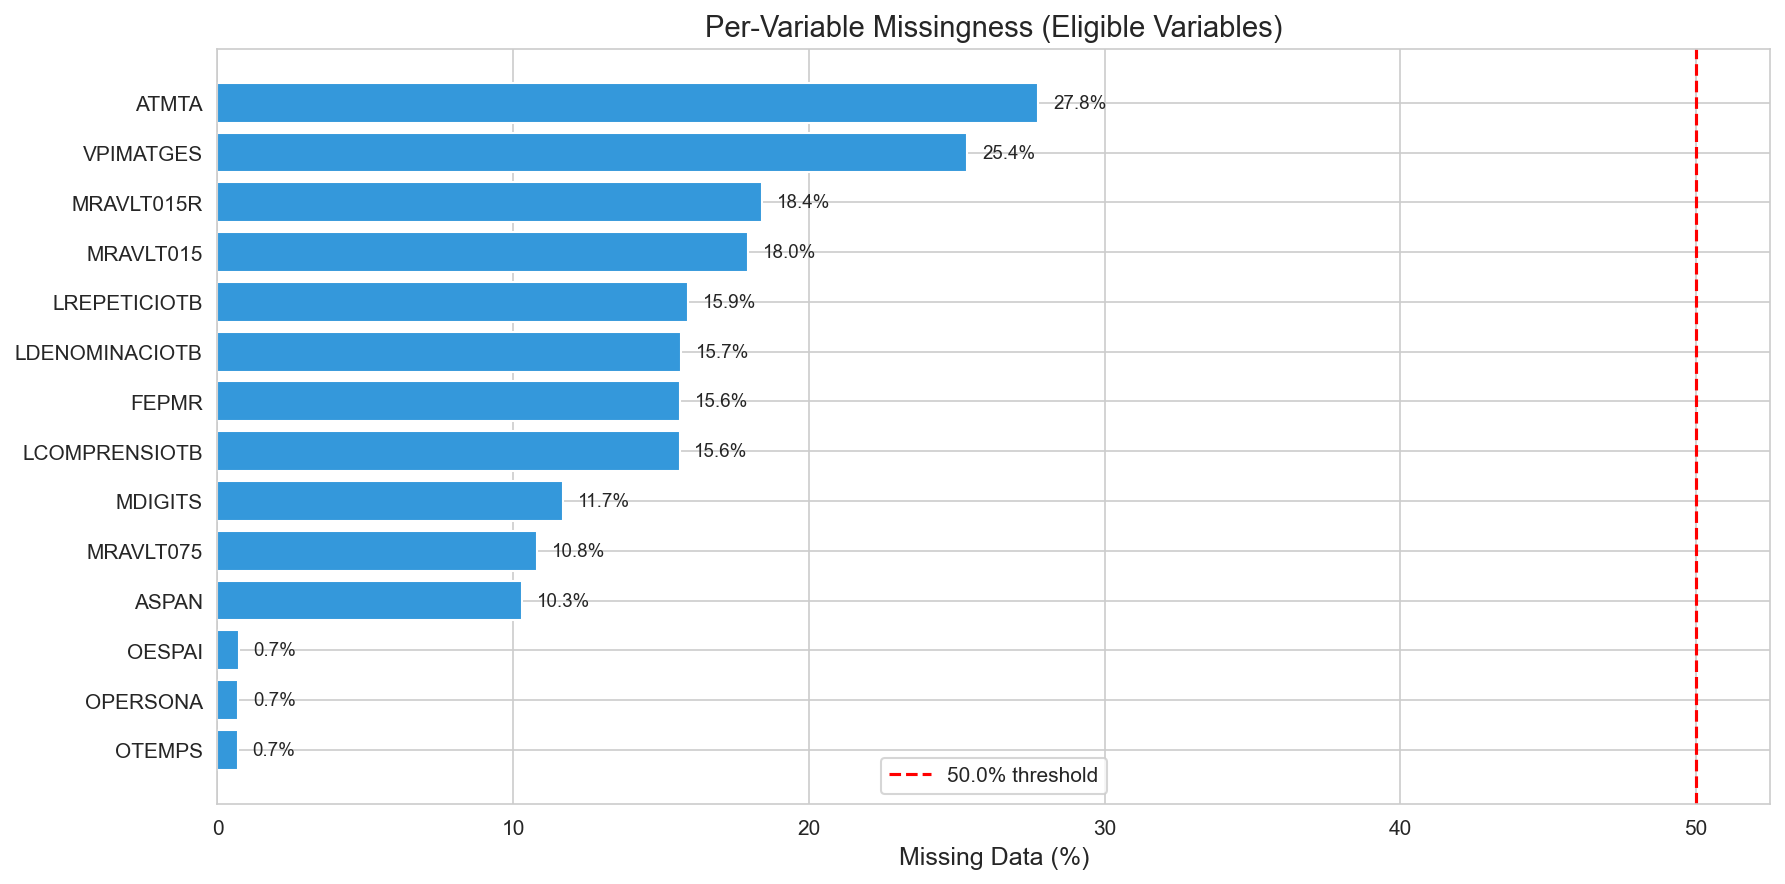

Saved: missingness_barplot.png


In [10]:
# Figure 1: Missingness bar chart
fig, ax = plt.subplots(figsize=(12, 6))

miss_eligible = df_eligible[ELIGIBLE_VARS].isnull().mean().sort_values(ascending=True) * 100
colors = ['#e74c3c' if v >= MISS_THRESHOLD else '#3498db' for v in miss_eligible.values]

bars = ax.barh(range(len(miss_eligible)), miss_eligible.values, color='#3498db', edgecolor='white')
ax.set_yticks(range(len(miss_eligible)))
ax.set_yticklabels(miss_eligible.index, fontsize=10)
ax.set_xlabel('Missing Data (%)', fontsize=12)
ax.set_title('Per-Variable Missingness (Eligible Variables)', fontsize=14)
ax.axvline(x=MISS_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'{MISS_THRESHOLD}% threshold')
ax.legend(fontsize=10)

for i, v in enumerate(miss_eligible.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'missingness_barplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: missingness_barplot.png')

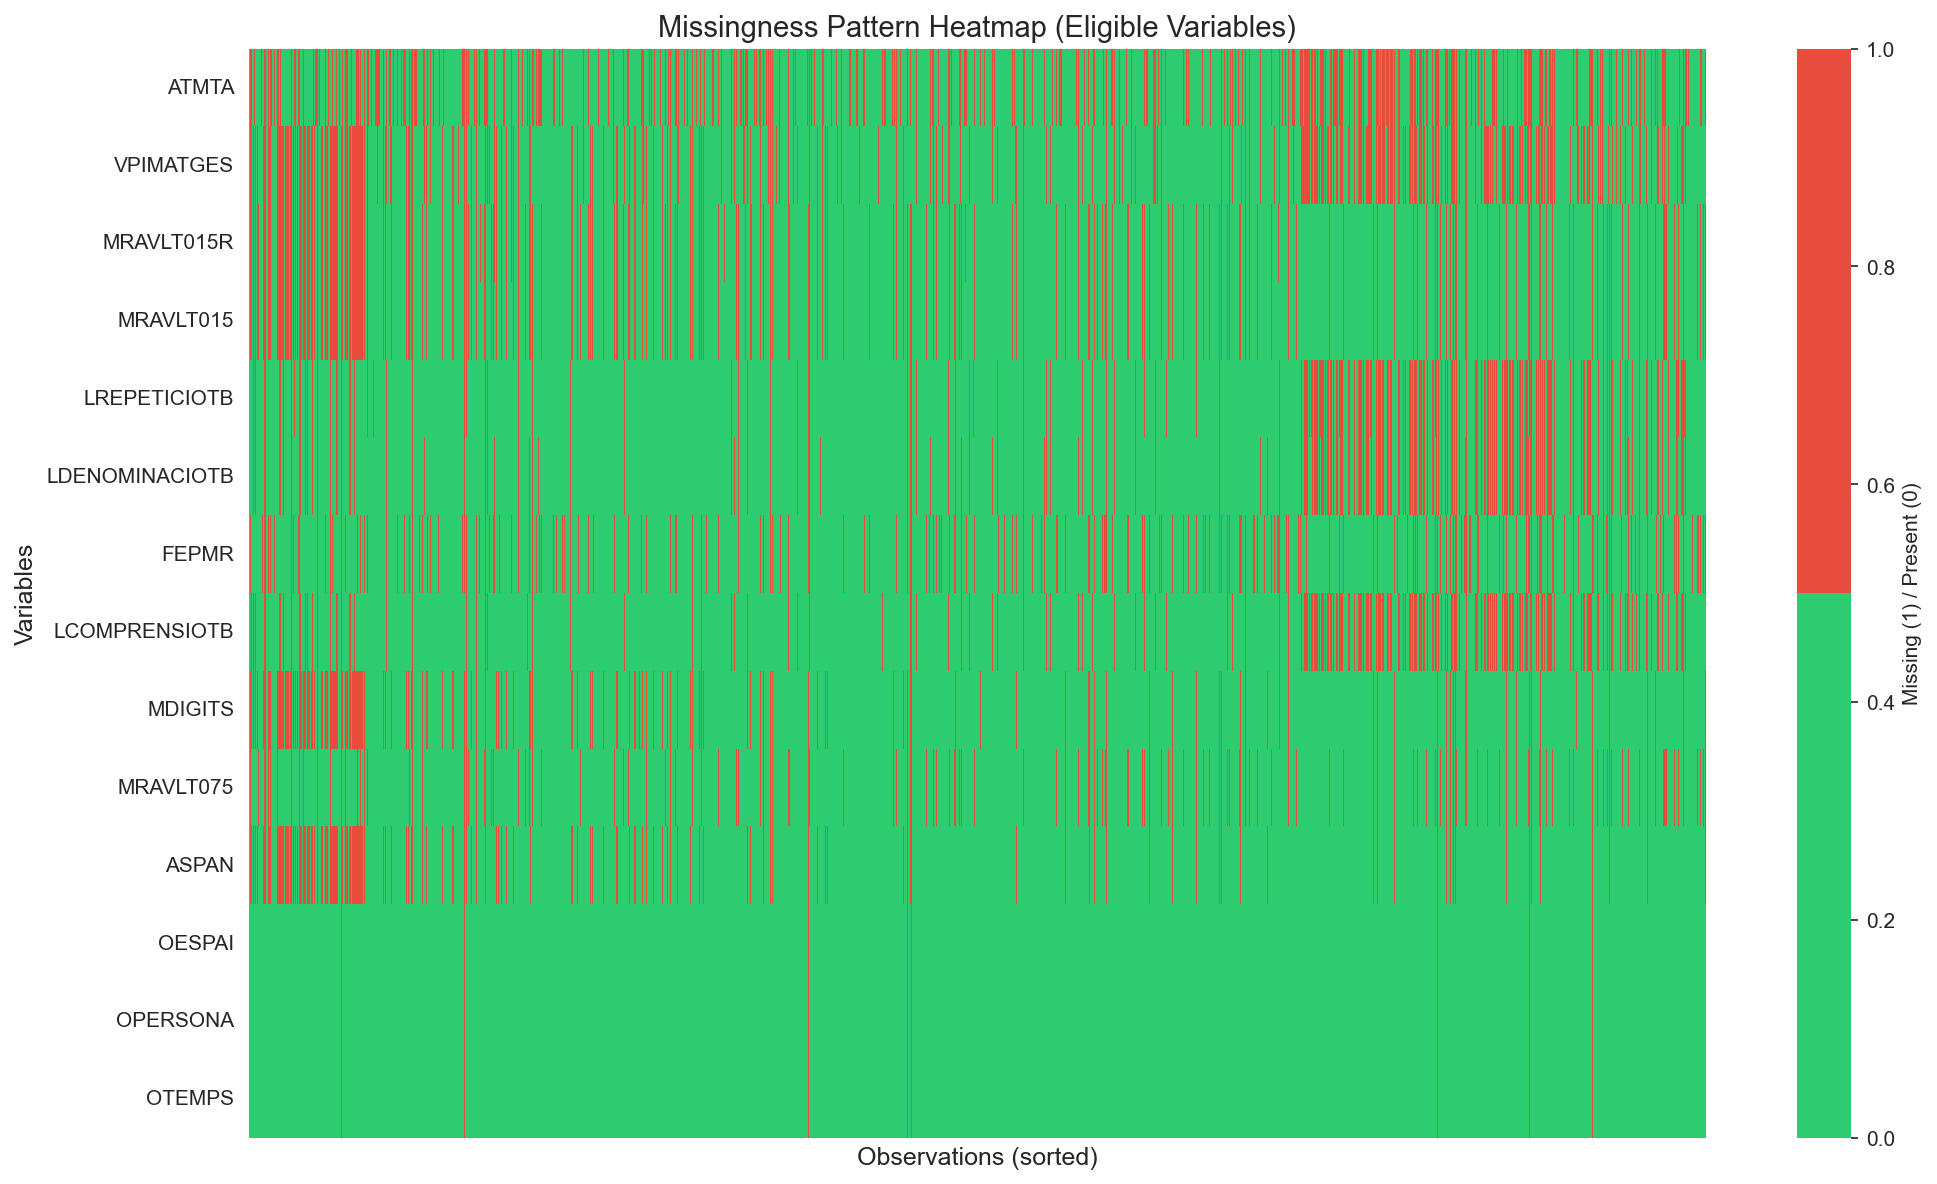

Saved: missingness_heatmap.png


In [11]:
# Figure 2: Missingness heatmap (variables x subsample of observations)
fig, ax = plt.subplots(figsize=(14, 8))

# Sort variables by missingness rate for better visualisation
sorted_vars = df_eligible[ELIGIBLE_VARS].isnull().mean().sort_values(ascending=False).index.tolist()

# Subsample for visualisation (show every nth row)
n_display = min(2000, len(df_eligible))
step = max(1, len(df_eligible) // n_display)
display_data = df_eligible[sorted_vars].iloc[::step].isnull().astype(int)

sns.heatmap(display_data.T, cmap=['#2ecc71', '#e74c3c'], cbar_kws={'label': 'Missing (1) / Present (0)'},
            yticklabels=sorted_vars, xticklabels=False, ax=ax)
ax.set_xlabel('Observations (sorted)', fontsize=12)
ax.set_ylabel('Variables', fontsize=12)
ax.set_title('Missingness Pattern Heatmap (Eligible Variables)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'missingness_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: missingness_heatmap.png')

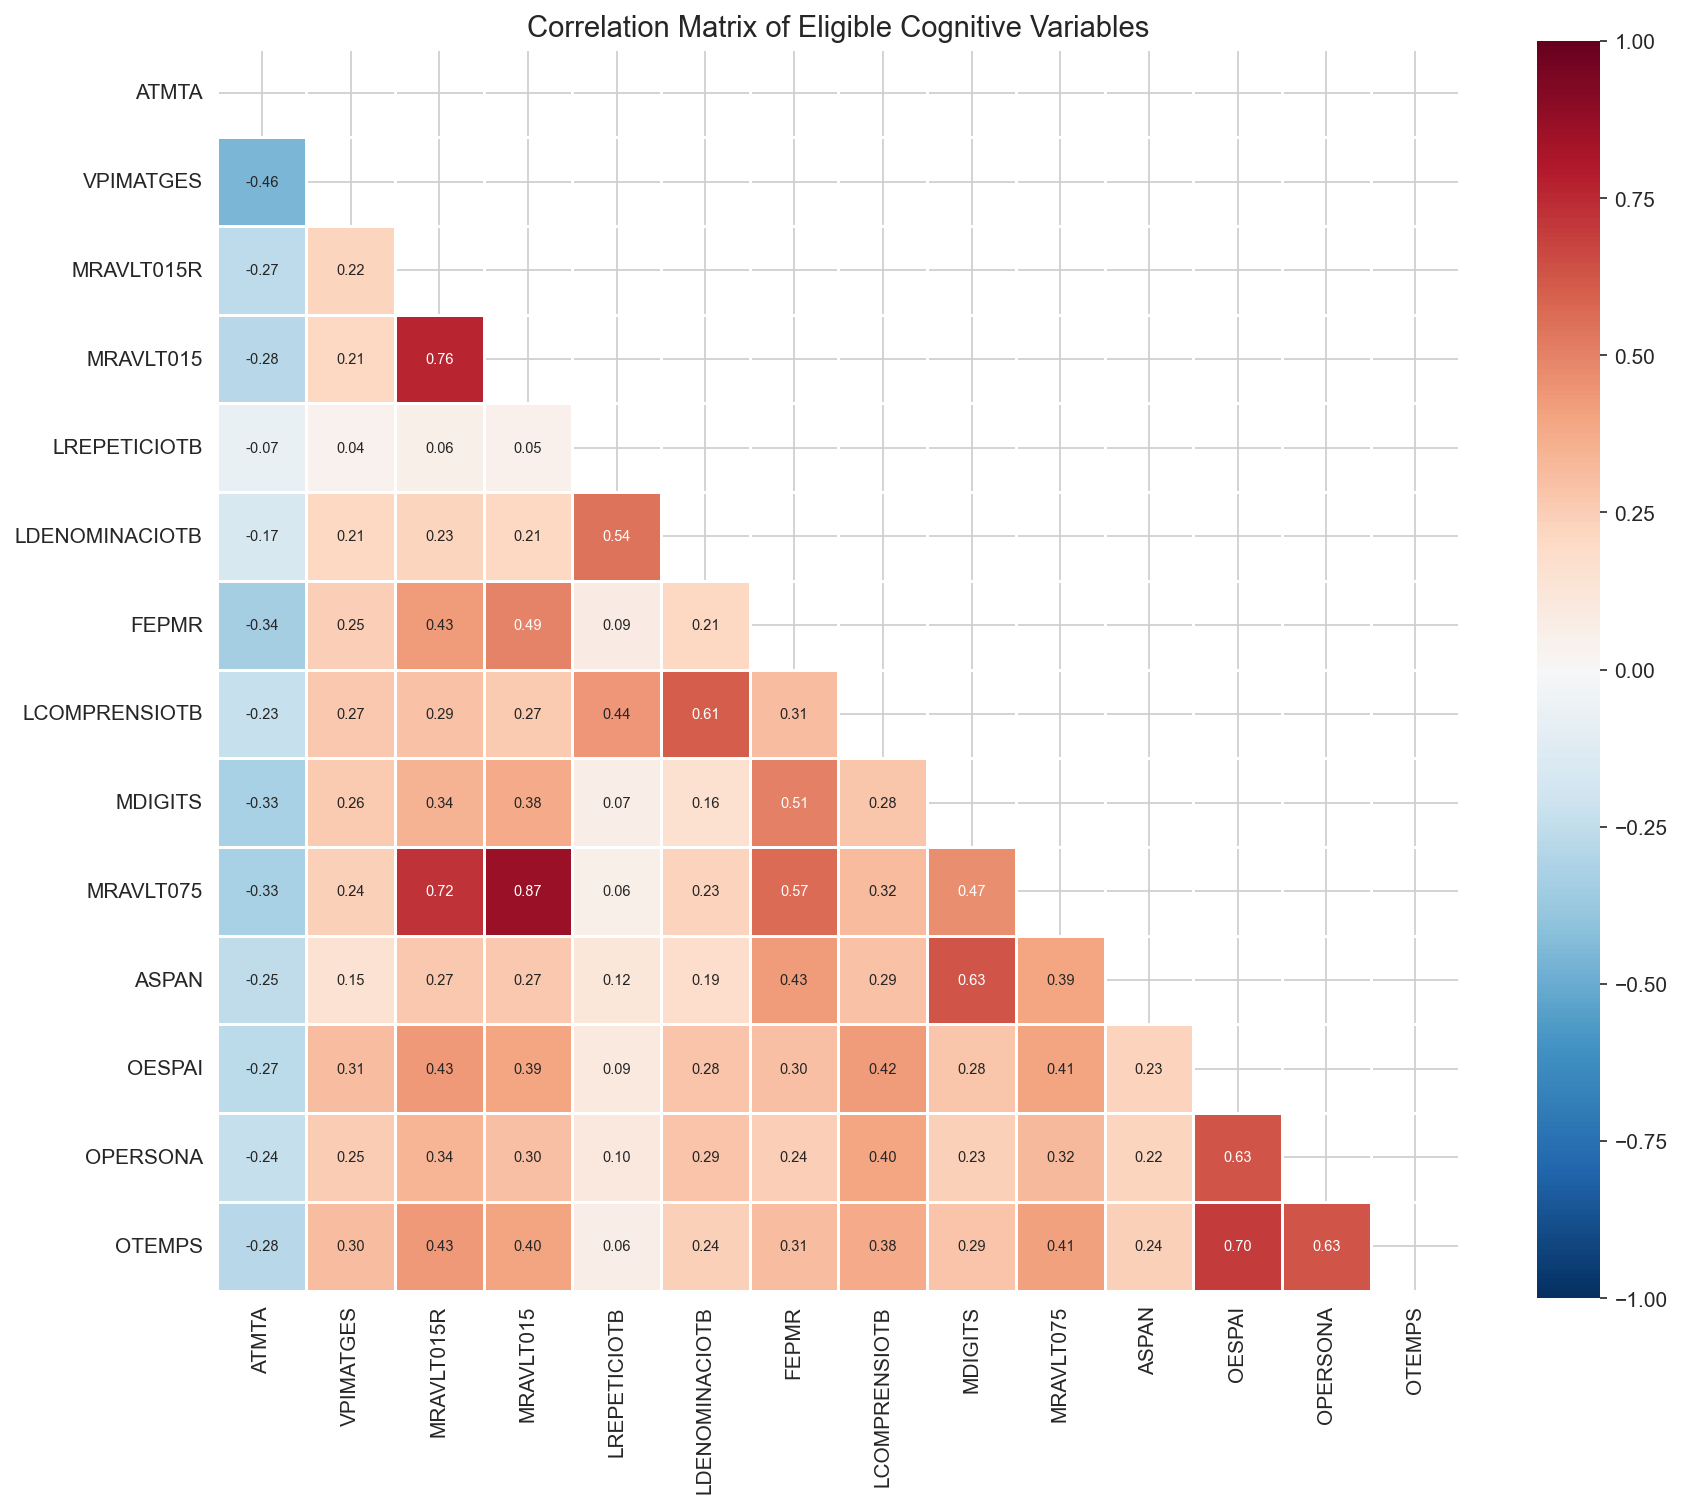

Saved: correlation_matrix.png


In [12]:
# Figure 3: Correlation matrix of eligible variables
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df_eligible[ELIGIBLE_VARS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix of Eligible Cognitive Variables', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: correlation_matrix.png')

In [13]:
# Domain-level missingness summary table
domain_summary = []
for domain, variables in DOMAINS.items():
    miss_mean = df_eligible[variables].isnull().mean().mean() * 100
    domain_summary.append({
        'Domain': domain,
        '# Variables': len(variables),
        'Variables': ', '.join(variables),
        'Mean Missing %': round(miss_mean, 1)
    })

domain_summary_df = pd.DataFrame(domain_summary)
print('=== Domain-Level Missingness Summary ===')
print(domain_summary_df.to_string(index=False))

=== Domain-Level Missingness Summary ===
            Domain  # Variables                                   Variables  Mean Missing %
       Orientation            3                    OPERSONA, OESPAI, OTEMPS             0.7
         Attention            2                                ASPAN, ATMTA            19.0
   Visuoperception            1                                   VPIMATGES            25.4
          Language            3 LREPETICIOTB, LDENOMINACIOTB, LCOMPRENSIOTB            15.7
            Memory            4   MDIGITS, MRAVLT075, MRAVLT015, MRAVLT015R            14.7
Executive Function            1                                       FEPMR            15.6


In [14]:
# Save outputs for downstream notebooks
import pickle

eda_output = {
    'ELIGIBLE_VARS': ELIGIBLE_VARS,
    'DOMAINS': DOMAINS,
    'df_eligible': df_eligible,
    'n_rows_eligible': len(df_eligible),
    'miss_threshold': MISS_THRESHOLD
}

with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'wb') as f:
    pickle.dump(eda_output, f, protocol=4)

# Also save just the eligible data matrix for imputation
df_eligible[ELIGIBLE_VARS].to_csv(os.path.join(RESULTS_DIR, 'eligible_data_matrix.csv'), index=True)

print(f'Saved eda_output.pkl ({len(ELIGIBLE_VARS)} eligible vars, {len(df_eligible):,} rows)')
print(f'Saved eligible_data_matrix.csv')
print('\n=== Notebook 0 Complete ===')

Saved eda_output.pkl (14 eligible vars, 17,406 rows)
Saved eligible_data_matrix.csv

=== Notebook 0 Complete ===
